In [25]:
from src.classification import run_classification_workflow
from src.basic_statistics import run_statistics_workflow
from src.segmentation import run_segmentation_workflow

In [26]:
path = "./data/Sentinel2A_subset_bands_ToA_BGRNirSWIR1SWIR2.tif"

Loading Sentinel-2 image...
Image loaded: (1288, 1320)
Calculating spectral indices...
Performing K-means segmentation with 6 clusters...


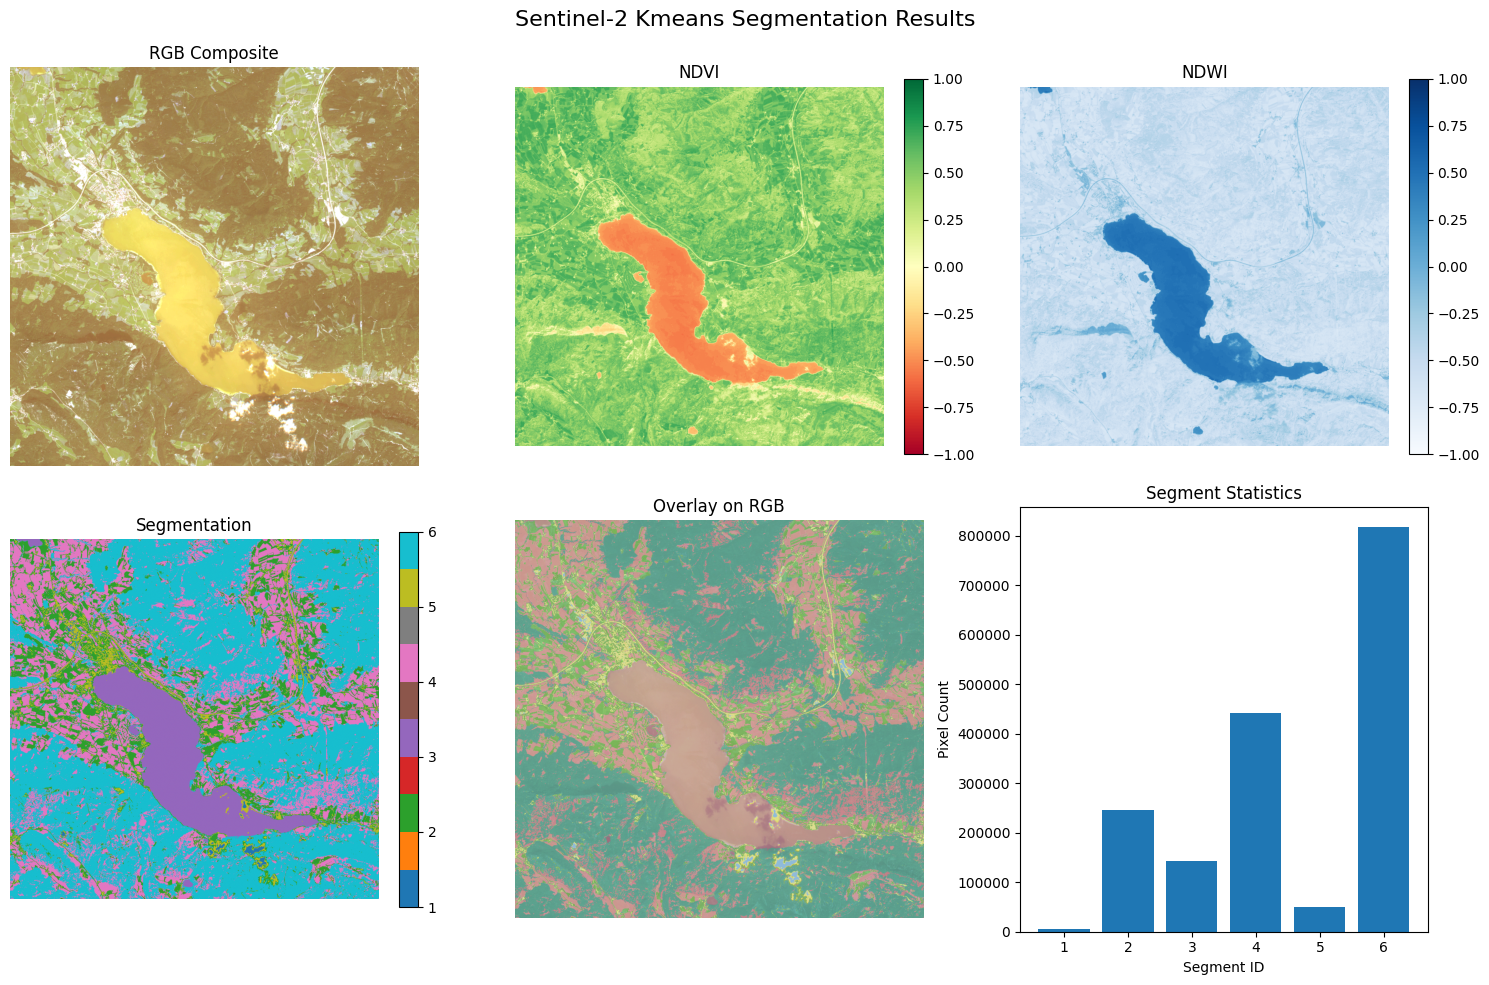


Segmentation Statistics:
segment_1: 5514 pixels, NDVI: 0.176, NDWI: -0.162
segment_2: 244817 pixels, NDVI: 0.474, NDWI: -0.480
segment_3: 142796 pixels, NDVI: -0.484, NDWI: 0.435
segment_4: 440924 pixels, NDVI: 0.611, NDWI: -0.621
segment_5: 49239 pixels, NDVI: 0.267, NDWI: -0.273
segment_6: 816870 pixels, NDVI: 0.411, NDWI: -0.490


In [27]:
segments = run_segmentation_workflow(path, method='kmeans')[2]

Loading image for statistics...
Extracting objects...
Found 6 objects
Calculating spectral statistics...
Calculating geometric statistics...
Calculating texture statistics...
Merging all statistics...
Statistics calculated for 6 objects


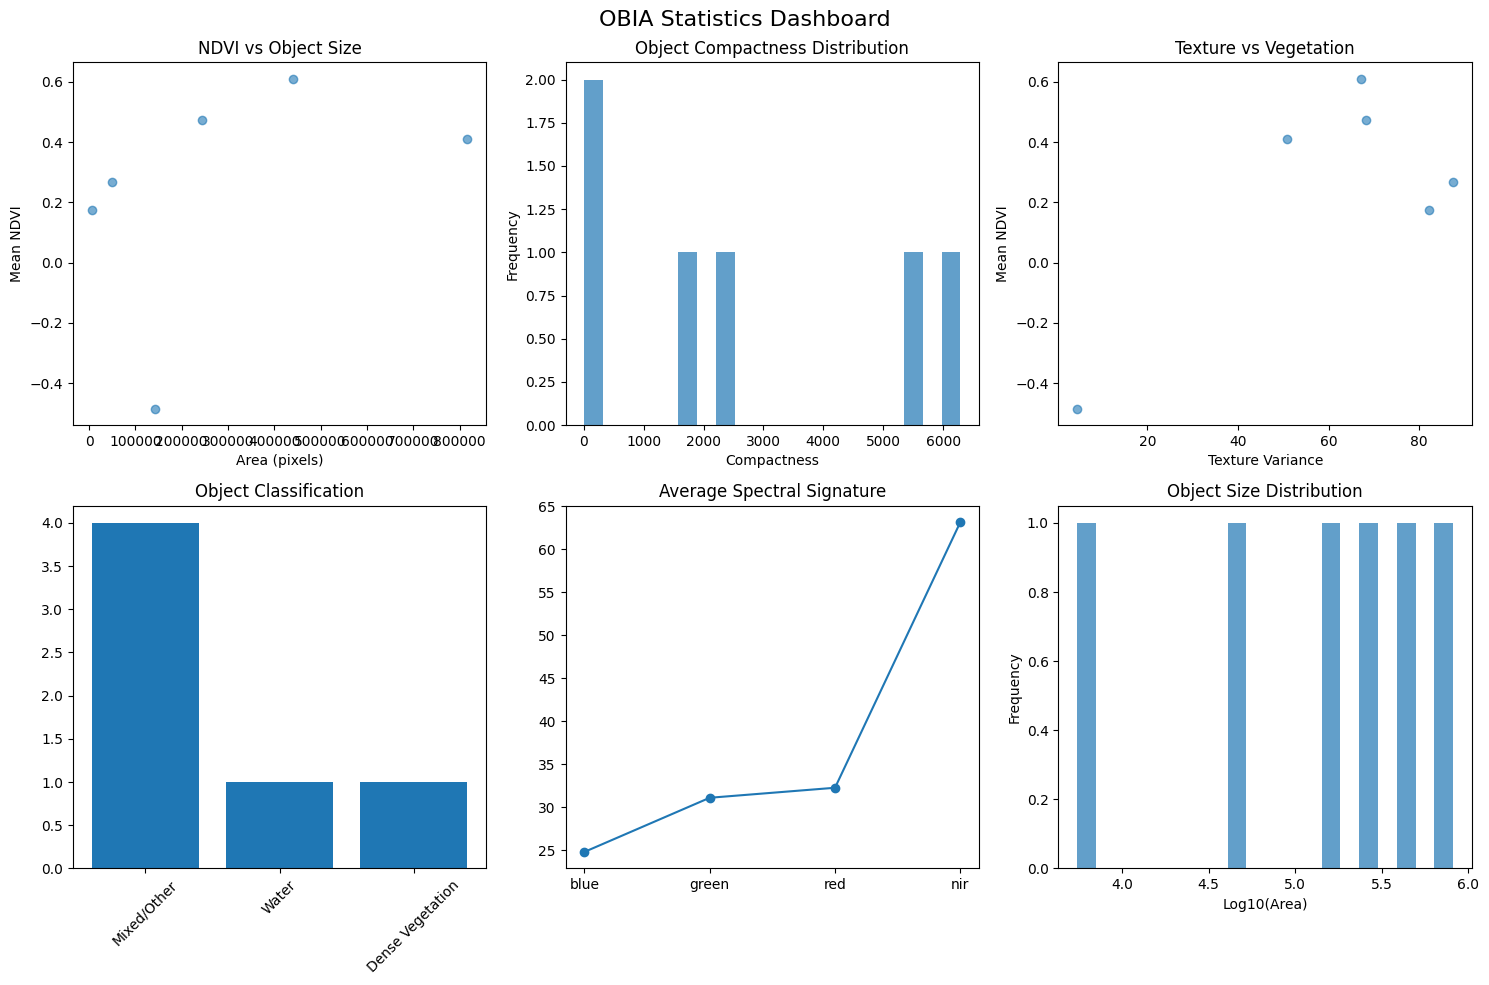


=== OBIA STATISTICS SUMMARY ===
Total objects analyzed: 6
Total area covered: 1700160.0 pixels
Average object size: 283360.0 pixels
Size range: 5514.0 - 816870.0 pixels

Spectral Statistics:
Mean NDVI: 0.242 ± 0.387
Mean NDWI: -0.265 ± 0.381

Classification Results:
  Mixed/Other: 4 objects (66.7%)
  Water: 1 objects (16.7%)
  Dense Vegetation: 1 objects (16.7%)


In [36]:
stats_df = run_statistics_workflow(path, segments=segments)[0]

In [37]:
combined_segmentation_classification_workflow(path, segmentation_method='kmeans')

NameError: name 'combined_segmentation_classification_workflow' is not defined

In [35]:
run_classification_workflow(path, segments=segments, stats_df=stats_df)

Preparing features...
Creating training labels...
Training samples per class:
labels
Mixed    3
Water    1
Name: count, dtype: int64
   object_id  blue_mean  blue_std  blue_median  green_mean  green_std  \
1          2  19.939360  2.925967         19.0   25.827137   1.983442   
2          3  12.648540  1.754064         12.0   26.719769   2.744208   
4          5  31.653019  6.024937         30.0   33.713924   4.440746   
5          6  10.168532  1.163433         10.0   17.086432   1.272996   

   green_median   red_mean   red_std  red_median  ...  compactness  \
1          26.0  26.103546  1.684879        26.0  ...  5417.598599   
2          27.0  30.149668  1.978694        31.0  ...    11.025115   
4          33.0  34.120594  4.334315        33.0  ...  1805.620325   
5          17.0  20.806948  0.878924        21.0  ...  2469.521022   

   eccentricity  solidity    extent  aspect_ratio  texture_variance  \
1      0.635034  0.144221  0.143996      1.294525         68.295555   
2      0

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.